# Spam Classifier - Full Pipeline
**Flow:** Data Loading → Preprocessing → Feature Engineering → Vectorization → Train/Test Split → Model Training → Evaluation

## 1. Basic Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
%matplotlib inline

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')   # Required in newer NLTK versions

print('All imports successful!')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


All imports successful!


## 2. Load Data

In [2]:
# Read the CSV file (encoding fix for special characters)
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Data Cleaning

In [3]:
# Drop unnecessary unnamed columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

# Rename columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Check for null values
print('Null values:\n', df.isnull().sum())

Null values:
 target    0
text      0
dtype: int64


In [5]:
# Check duplicates
print('Duplicate rows:', df.duplicated().sum())
print('Total rows before drop:', len(df))

# Remove duplicates
df = df.drop_duplicates(keep='first')
print('Total rows after drop:', len(df))

Duplicate rows: 403
Total rows before drop: 5572
Total rows after drop: 5169


## 4. Data Preprocessing

In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode target: ham -> 0, spam -> 1
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Class distribution:
target
0    4516
1     653
Name: count, dtype: int64


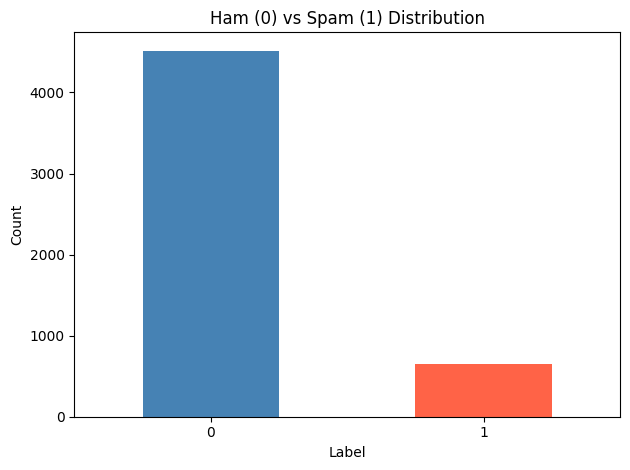

In [7]:
# Class distribution
print('Class distribution:')
print(df['target'].value_counts())

df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Ham (0) vs Spam (1) Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Feature Engineering (Text Preprocessing)

In [8]:
# Initialize Porter Stemmer
ps = PorterStemmer()

def transform_text(text):
    """Lowercase, tokenize, remove stopwords/punctuation, and stem."""
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Tokenize
    text = nltk.word_tokenize(text)

    # Step 3: Keep only alphanumeric tokens
    y = [i for i in text if i.isalnum()]

    # Step 4: Remove stopwords and punctuation
    y = [i for i in y if i not in stopwords.words('english') and i not in string.punctuation]

    # Step 5: Stemming
    y = [ps.stem(i) for i in y]

    return " ".join(y)

# Quick test
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [9]:
# Apply text transformation to all rows
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 6. WordCloud Visualization

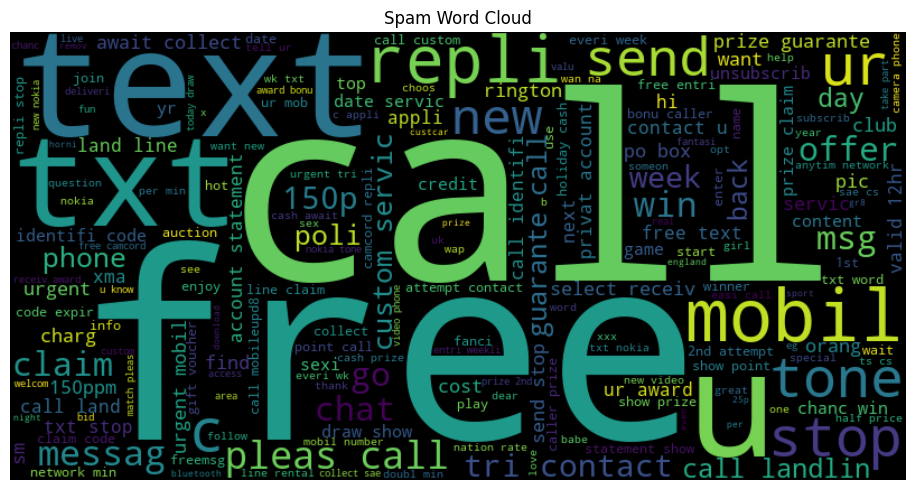

In [10]:
# WordCloud for Spam messages
spam_corpus = " ".join(df[df['target'] == 1]['transformed_text'])
wc_spam = WordCloud(width=800, height=400, background_color='black').generate(spam_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Word Cloud')
plt.tight_layout()
plt.show()

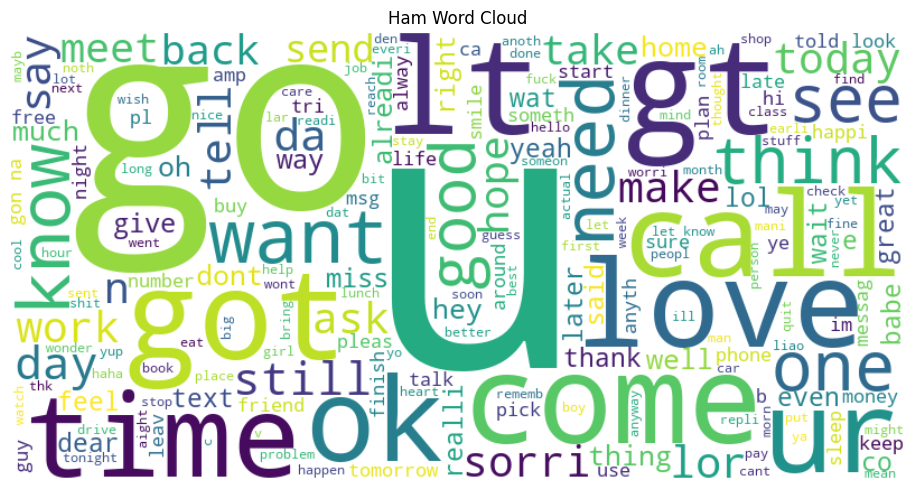

In [11]:
# WordCloud for Ham messages
ham_corpus = " ".join(df[df['target'] == 0]['transformed_text'])
wc_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Ham Word Cloud')
plt.tight_layout()
plt.show()

## 7. Vectorization (TF-IDF)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

print('Feature matrix shape:', X.shape)
print('Target array shape:', y.shape)

Feature matrix shape: (5169, 500)
Target array shape: (5169,)


## 8. Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (4135, 500)
Test size: (1034, 500)


## 9. Model Training

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

# Define all classifiers
clfs = {
    'SVC'     : SVC(kernel='sigmoid', gamma=1.0),
    'KNN'     : KNeighborsClassifier(),
    'NB'      : MultinomialNB(),
    'DT'      : DecisionTreeClassifier(max_depth=5),
    'LR'      : LogisticRegression(solver='liblinear', penalty='l1'),
    'RF'      : RandomForestClassifier(n_estimators=50, random_state=2),
    'Adaboost': AdaBoostClassifier(n_estimators=50, random_state=2),
    'Bagging' : BaggingClassifier(n_estimators=50, random_state=2),
    'ETC'     : ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GBDT'    : GradientBoostingClassifier(n_estimators=50, random_state=2),
    'XGB'     : XGBClassifier(n_estimators=50, random_state=2, eval_metric='logloss')
}

## 10. Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, precision_score

def train_classifier(clf, X_train, y_train, X_test, y_test):
    """Train a classifier and return accuracy and precision."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision


# FIXED: Use a separate variable for the loop (avoid overwriting clfs dict)
accuracy_scores  = []
precision_scores = []
model_names      = []

for name, clf in clfs.items():          # <-- 'clf' not 'clfs' to avoid shadowing the dict
    acc, prec = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    model_names.append(name)
    print(f'[{name}]  Accuracy: {acc:.4f}  |  Precision: {prec:.4f}')

[SVC]  Accuracy: 0.9662  |  Precision: 0.9328
[KNN]  Accuracy: 0.9275  |  Precision: 1.0000
[NB]  Accuracy: 0.9710  |  Precision: 0.9655
[DT]  Accuracy: 0.9381  |  Precision: 0.9022
[LR]  Accuracy: 0.9632  |  Precision: 0.9630
[RF]  Accuracy: 0.9729  |  Precision: 0.9435
[Adaboost]  Accuracy: 0.9236  |  Precision: 0.8734
[Bagging]  Accuracy: 0.9632  |  Precision: 0.9098
[ETC]  Accuracy: 0.9749  |  Precision: 0.9375
[GBDT]  Accuracy: 0.9516  |  Precision: 0.9314
[XGB]  Accuracy: 0.9700  |  Precision: 0.9496


## 11. Results Comparison

In [16]:
# Summary DataFrame
results_df = pd.DataFrame({
    'Model'    : model_names,
    'Accuracy' : accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

   Model  Accuracy  Precision
     KNN  0.927466   1.000000
      NB  0.970986   0.965517
      LR  0.963250   0.962963
     XGB  0.970019   0.949580
      RF  0.972921   0.943548
     ETC  0.974855   0.937500
     SVC  0.966151   0.932773
    GBDT  0.951644   0.931373
 Bagging  0.963250   0.909836
      DT  0.938104   0.902174
Adaboost  0.923598   0.873418


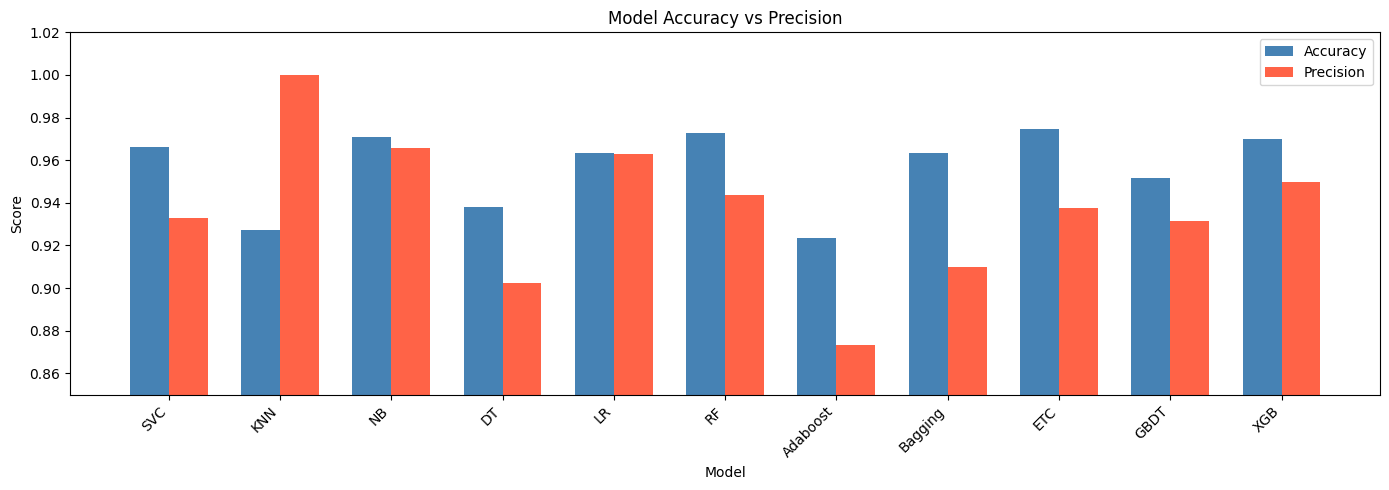

In [17]:
# Bar chart comparison
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, accuracy_scores,  width, label='Accuracy',  color='steelblue')
ax.bar(x + width/2, precision_scores, width, label='Precision', color='tomato')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Accuracy vs Precision')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylim(0.85, 1.02)
ax.legend()
plt.tight_layout()
plt.show()